In [15]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, precision_score, recall_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from pygam import LogisticGAM, s
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Load and balance dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Landslide_ML_CSV.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["wkt_geom"], inplace=True, errors="ignore")

class_0 = df[df["Target_Var"] == 0].sample(n=1746, random_state=42)
class_1 = df[df["Target_Var"] == 1].sample(n=1746, random_state=42)
df_balanced = pd.concat([class_0, class_1]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_balanced.drop(columns=["Target_Var"]).fillna(0)
y = df_balanced["Target_Var"]

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection using Random Forest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train)
sfm = SelectFromModel(rf_selector, prefit=True, threshold="median")
X_train_selected = sfm.transform(X_train_scaled)
X_test_selected = sfm.transform(X_test_scaled)

# Evaluation function
def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    print(f"\n================ {name} =================")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("AUC ROC:", roc_auc_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))


# ====================== SVM ======================
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf']
}
svm = GridSearchCV(SVC(probability=True), svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm.fit(X_train_selected, y_train)
evaluate_model("SVM (Tuned)", svm.best_estimator_, X_test_selected, y_test)


================ SVM (Tuned) =================
Accuracy: 0.8129770992366412
Precision: 0.7907801418439716
Recall: 0.851145038167939
AUC ROC: 0.8129770992366412
Confusion Matrix:
 [[406 118]
 [ 78 446]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.81       524
           1       0.79      0.85      0.82       524

    accuracy                           0.81      1048
   macro avg       0.81      0.81      0.81      1048
weighted avg       0.81      0.81      0.81      1048



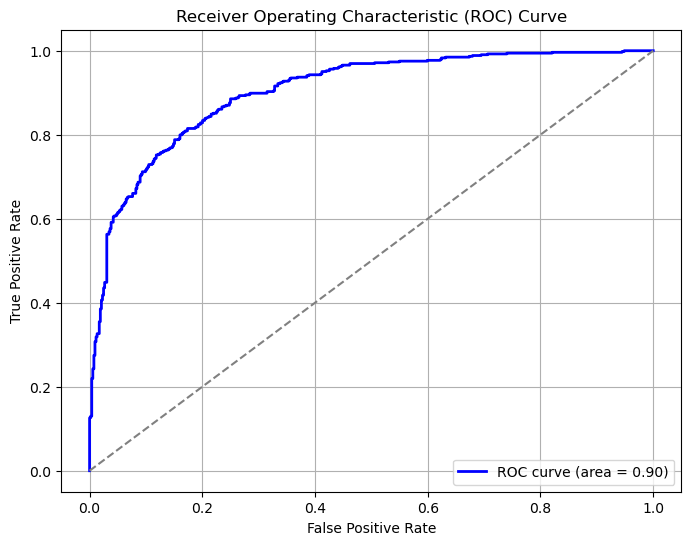

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 3. Generate predictions and calculate ROC curve
probs = svm.predict_proba(X_test_selected)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# 4. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [21]:
import pandas as pd

# Predict class labels
y_pred_svm = svm.predict(X_test_selected)
probs = svm.predict_proba(X_test_selected)[:, 1]

# Create DataFrame
df_svm = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': probs,
    'Predicted_Label': y_pred_svm
})

# Save to CSV
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SVM_Landslide_Results.csv"
df_svm.to_csv(save_path, index=False)


PermutationExplainer explainer: 1049it [51:39,  2.96s/it]                          


<Figure size 640x480 with 0 Axes>

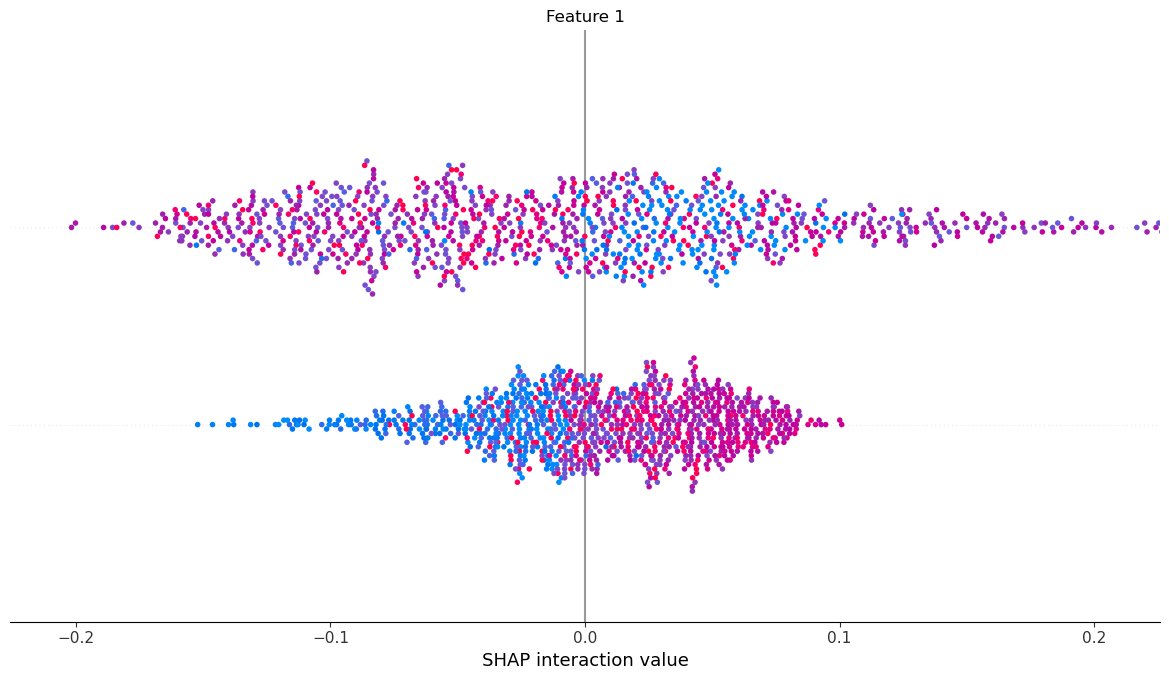

In [10]:
import shap

# 6. SHAP Analysis
explainer = shap.Explainer(svm.predict_proba, X_train_selected)
shap_values = explainer(X_test_selected)

# Summary plot
shap.summary_plot(shap_values, X_test_selected)